<a href="https://colab.research.google.com/github/oscmoral/Programacion-para-analitica-descriptiva-y-predictiva/blob/main/Practica01_semana11_Regresion_lineal_multiple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Marzo 2025
## Práctica: Práctica: Regresión Lineal Múltiple
---


## Datos del Estudiante

*   Apellidos y Nombre: Oscar Morales Martinez
*   Matrícula: 266223

---



##  Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de **aplicar regresión lineal múltiple utilizando Scikit-Learn para modelar la relación entre varias variables independientes y una variable dependiente**, verificar los supuestos del modelo, interpretar los coeficientes, analizar la correlación entre predictores y evaluar el rendimiento del modelo utilizando métricas como el MSE, RMSE y R².

Datos
Trabajarás con el archivo `advertising.csv`, que contiene información sobre el gasto publicitario en diferentes medios y las ventas obtenidas:

-`TV`: inversión en publicidad televisiva.

-`Radio`: inversión en publicidad en radio.

-`Newspaper`: inversión en publicidad en periódicos.

`Sales`: ventas del producto (variable dependiente).

## Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `advertising.csv`.
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente las variables.

In [10]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

path = "/content/drive/MyDrive/ClassFiles/advertising.csv"
df = pd.read_csv(path)

print("Primeras 10 filas del dataframe:")
display(df.head(10))

print("\nEstadistica de las variables:")
display(df.describe())

Primeras 10 filas del dataframe:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6



Estadistica de las variables:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## Parte 2: Análisis exploratorio de los datos
### 2.1  Análisis de la Relación Lineal entre la variable dependiente y las independientes
1. Grafica dispersión entre cada variable independiente (`TV`, `Radio`, `Newspaper`) y `Sales`. Usa también regplot.
2. Interpreta visualmente la relación entre variables.

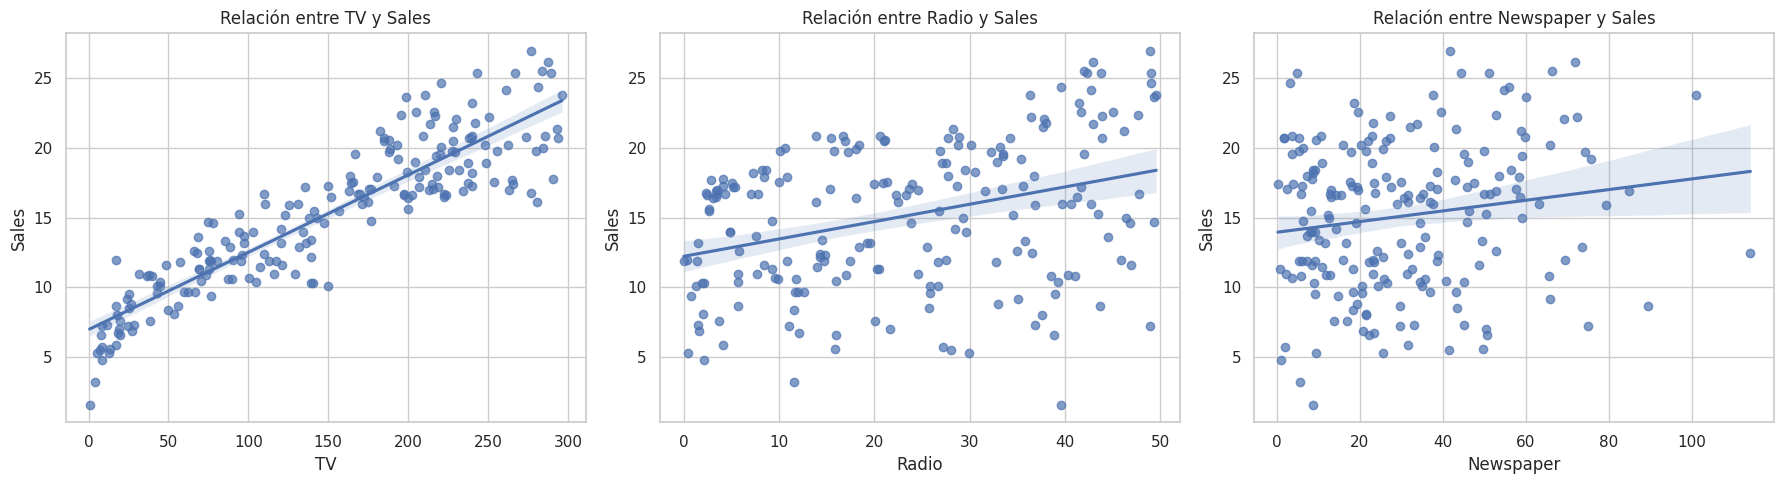

In [6]:
# Gráficos de dispersión
sns.set_theme(style="whitegrid")

independent_vars = ["TV", "Radio", "Newspaper"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var in zip(axes, independent_vars):
    sns.regplot(data=df, x=var, y="Sales", ax=ax, scatter_kws={"alpha": 0.7})
    ax.set_title(f"Relación entre {var} y Sales")
    ax.set_xlabel(var)
    ax.set_ylabel("Sales")

plt.tight_layout()
plt.show()

### 2.2: Correlación entre variables
1. Calcula la matriz de correlación.
2. Visualízala con un heatmap.
3. Responde: ¿Qué variables están más correlacionadas con `Sales`? ¿Hay correlación alta entre predictores?

Matriz de correlación:


,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


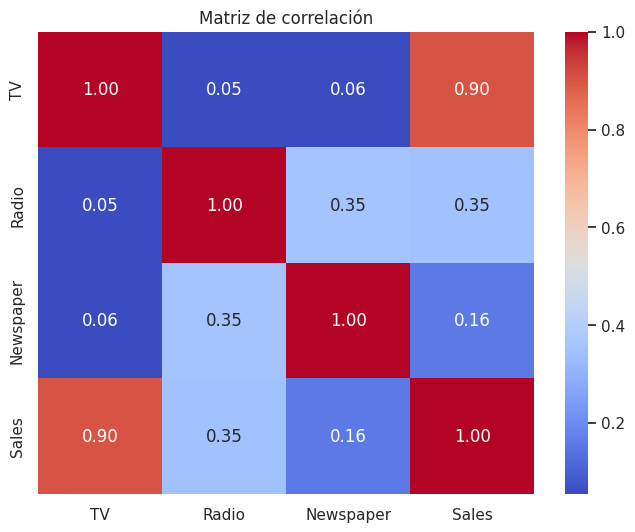

¿Qué variables están más correlacionadas con Sales? ¿Hay correlación alta entre predictores?
- La variable más correlacionada con Sales es TV.
- Radio tiene una correlación positiva moderada con Sales.
- Newspaper tiene una correlación baja con Sales.
- No se observa una correlación alta entre predictores; por lo tanto, no parece haber multicolinealidad fuerte.


In [11]:
# Correlación y heatmap
corr_matrix = df.corr(numeric_only=True)

print("Matriz de correlación:")
display(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

print("¿Qué variables están más correlacionadas con Sales? ¿Hay correlación alta entre predictores?")
print("- La variable más correlacionada con Sales es TV.")
print("- Radio tiene una correlación positiva moderada con Sales.")
print("- Newspaper tiene una correlación baja con Sales.")
print("- No se observa una correlación alta entre predictores; por lo tanto, no parece haber multicolinealidad fuerte.")

## Parte 3. Multicolinealidad
1. Calcula el VIF (Variance Inflation Factor) para cada predictor.
2. Crea un diagrama de barras  para mostrar el  VIF
3. Interpreta si hay multicolinealidad:
- ¿Alguna variable tiene un VIF mayor a 5 o mayor a 10?
- ¿Qué implicaciones tiene esto para el modelo?

Valores VIF:


,Variable,VIF
1,TV,1.004611
2,Radio,1.144952
3,Newspaper,1.145187


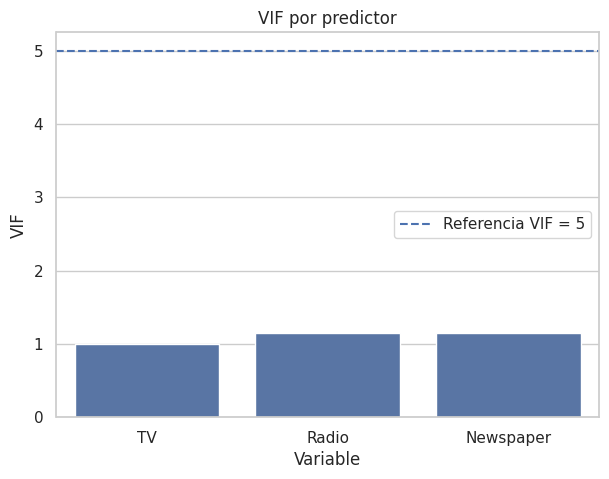

Interpretación:
- Ninguna variable tiene VIF mayor a 5 ni mayor a 10.
- Esto indica que no hay evidencia de multicolinealidad problemática entre los predictores.
- Por esta razón, no es necesario eliminar variables por multicolinealidad.


In [14]:
#Multicolinealidad
X_vif = df[["TV", "Radio", "Newspaper"]]
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]

# Quitamos la constante para interpretar solo predictores
vif_predictors = vif_data[vif_data["Variable"] != "const"].copy()

print("Valores VIF:")
display(vif_predictors)

plt.figure(figsize=(7, 5))
sns.barplot(data=vif_predictors, x="Variable", y="VIF")
plt.axhline(5, linestyle="--", label="Referencia VIF = 5")
plt.title("VIF por predictor")
plt.xlabel("Variable")
plt.ylabel("VIF")
plt.legend()
plt.show()

print("Interpretación:")
print("- Ninguna variable tiene VIF mayor a 5 ni mayor a 10.")
print("- Esto indica que no hay evidencia de multicolinealidad problemática entre los predictores.")
print("- Por esta razón, no es necesario eliminar variables por multicolinealidad.")

## Parte 4: Construcción del Modelo (Todas las variables Independientes), Evaluación

### 4.1 Entrenamiento del Modelo (Todas las Variables Independientes)

1. Entrena un modelo de regresión lineal múltiple usando TV, Radio y Newspaper como variables independientes.
2. Imprime el intercepto y los coeficientes del modelo.
3. Interpreta cada uno:
¿Qué significa cada uno de los coeficientes  en términos de ventas?

In [15]:
#ntrenamiento del Modelo (Todas las Variables Independientes)
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_all = LinearRegression()
model_all.fit(X_train, y_train)

y_pred_all = model_all.predict(X_test)

coefficients_all = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": model_all.coef_
})

print("Intercepto:", model_all.intercept_)
print("\nCoeficientes del modelo:")
display(coefficients_all)

print("Interpretación:")
print("- El intercepto representa las ventas estimadas cuando la inversión en los tres medios es 0.")
print("- El coeficiente de TV indica cuánto aumentan las ventas esperadas por cada unidad adicional invertida en TV, manteniendo las demás variables constantes.")
print("- El coeficiente de Radio se interpreta de la misma forma para radio.")
print("- El coeficiente de Newspaper es muy pequeño, lo que sugiere menor aporte al modelo al compararlo con TV y Radio.")

Intercepto: 4.714126402214127

Coeficientes del modelo:


,Variable,Coeficiente
0,TV,0.054509
1,Radio,0.100945
2,Newspaper,0.004337


Interpretación:
- El intercepto representa las ventas estimadas cuando la inversión en los tres medios es 0.
- El coeficiente de TV indica cuánto aumentan las ventas esperadas por cada unidad adicional invertida en TV, manteniendo las demás variables constantes.
- El coeficiente de Radio se interpreta de la misma forma para radio.
- El coeficiente de Newspaper es muy pequeño, lo que sugiere menor aporte al modelo al compararlo con TV y Radio.


### 4.2 Normalidad de los residuos

1. Calcula los residuos: residuos = y - y_pred.

2. Grafica un histograma con KDE de los residuos.

3. ¿Los residuos parecen distribuirse normalmente?

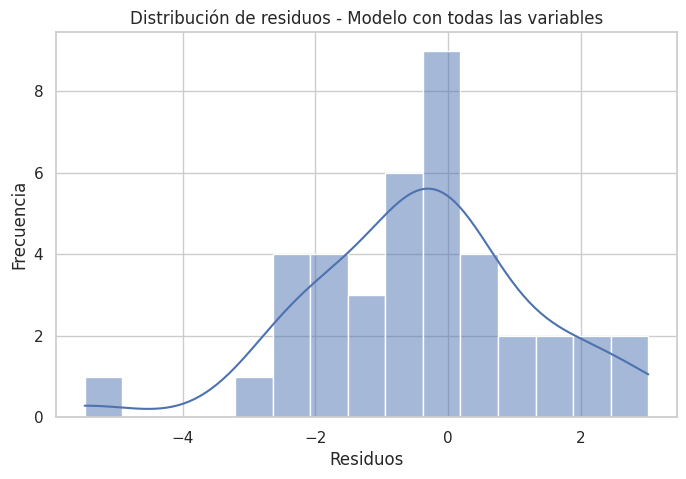

Prueba de Shapiro-Wilk para los residuos:
Estadístico: 0.9681297087107905
p-value: 0.3134976984995692
Interpretación:
- Como el p-value es mayor a 0.05, no se rechaza la hipótesis de normalidad de los residuos.


In [16]:
#Normalidad de los residuos
residuals_all = y_test - y_pred_all

plt.figure(figsize=(8, 5))
sns.histplot(residuals_all, kde=True, bins=15)
plt.title("Distribución de residuos - Modelo con todas las variables")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals_all)

print("Prueba de Shapiro-Wilk para los residuos:")
print("Estadístico:", shapiro_stat)
print("p-value:", shapiro_p)

print("Interpretación:")
if shapiro_p > 0.05:
    print("- Como el p-value es mayor a 0.05, no se rechaza la hipótesis de normalidad de los residuos.")
else:
    print("- Como el p-value es menor o igual a 0.05, se rechaza la hipótesis de normalidad de los residuos.")

### 4.3. Homocedasticidad

1. Grafica los residuos contra los valores predichos.
2. ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?

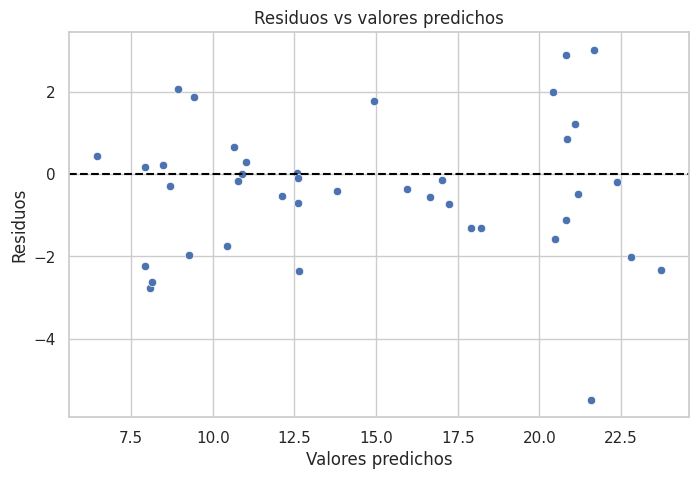

Interpretación:
- Se espera que los residuos se dispersen de manera aleatoria alrededor de 0.
- Si no se observa un patrón claro de embudo o curva, el supuesto de homocedasticidad parece razonable.


In [17]:
# Homocedasticidad
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_all, y=residuals_all)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residuos vs valores predichos")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.show()

print("Interpretación:")
print("- Se espera que los residuos se dispersen de manera aleatoria alrededor de 0.")
print("- Si no se observa un patrón claro de embudo o curva, el supuesto de homocedasticidad parece razonable.")

### 4.4 Q-Q Plot

1. Graficar el Q-Q Plot
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal, b) Desviaciones sistemáticas indican asimetría o colas pesadas.

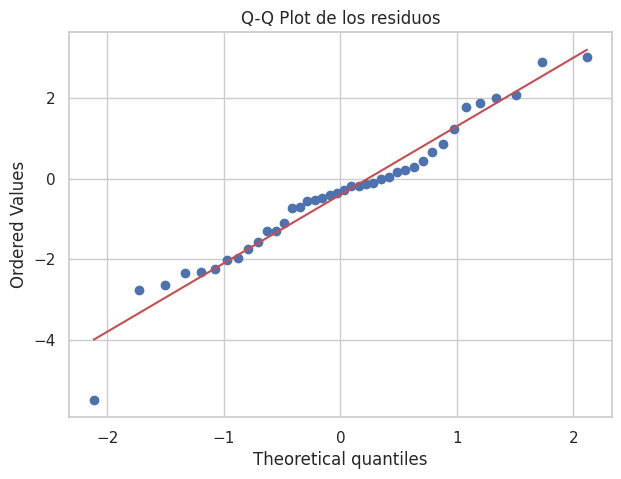

Interpretación:
- Si los puntos se aproximan a la línea diagonal, los residuos se comportan de forma similar a una distribución normal.
- Pequeñas desviaciones en los extremos pueden indicar colas más pesadas o algunos valores atípicos.


In [18]:
#Q-Q Plot
plt.figure(figsize=(7, 5))
stats.probplot(residuals_all, dist="norm", plot=plt)
plt.title("Q-Q Plot de los residuos")
plt.show()

print("Interpretación:")
print("- Si los puntos se aproximan a la línea diagonal, los residuos se comportan de forma similar a una distribución normal.")
print("- Pequeñas desviaciones en los extremos pueden indicar colas más pesadas o algunos valores atípicos.")

### 4.5. Evaluación del Modelo

1. Calcula las métricas: a) MSE (error cuadrático medio), b) RMSE (raíz del error cuadrático medio), c) R² (coeficiente de determinación)

2. ¿Qué nos dicen estas métricas sobre el ajuste del modelo?


In [19]:
#Evaluación del Modelo
mse_all = mean_squared_error(y_test, y_pred_all)
rmse_all = np.sqrt(mse_all)
r2_all = r2_score(y_test, y_pred_all)

metrics_all = pd.DataFrame({
    "Modelo": ["Todas las variables"],
    "MSE": [mse_all],
    "RMSE": [rmse_all],
    "R2": [r2_all]
})

display(metrics_all)

print("Interpretación:")
print("- El MSE y RMSE indican el error promedio del modelo; valores más bajos representan mejor ajuste.")
print("- El R2 indica qué proporción de la variabilidad de Sales es explicada por el modelo.")
print("- En este caso, el modelo explica una proporción alta de la variabilidad de las ventas.")

,Modelo,MSE,RMSE,R2
0,Todas las variables,2.907757,1.705215,0.905901


Interpretación:
- El MSE y RMSE indican el error promedio del modelo; valores más bajos representan mejor ajuste.
- El R2 indica qué proporción de la variabilidad de Sales es explicada por el modelo.
- En este caso, el modelo explica una proporción alta de la variabilidad de las ventas.


### 4.6. Visualización de Predicciones

1. Crea un gráfico comparando Sales reales vs Sales predichas.

2. Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.
3.¿Qué observas?¿Qué observas? ¿Qué información puedes obtener de esta gráfica?

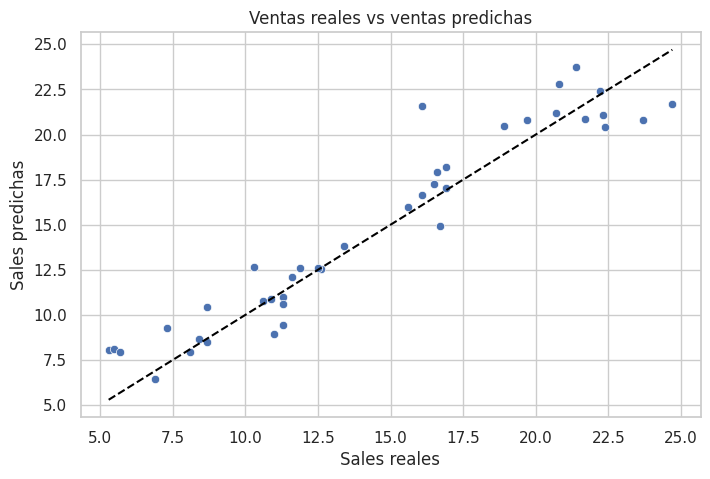

Interpretación:
- Si los puntos se acercan a la línea diagonal, el modelo predice correctamente.
- En general, se observa un buen ajuste, aunque existen algunas diferencias entre valores reales y predichos.


In [20]:
#Visualización de las Predicciones
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_all)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--", color="black")
plt.title("Ventas reales vs ventas predichas")
plt.xlabel("Sales reales")
plt.ylabel("Sales predichas")
plt.show()

print("Interpretación:")
print("- Si los puntos se acercan a la línea diagonal, el modelo predice correctamente.")
print("- En general, se observa un buen ajuste, aunque existen algunas diferencias entre valores reales y predichos.")

### 4.7 Verificar el impacto de los atributos en el modelo

1. Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
2. Interpreta los resultados:

 - Observa los valores P>|t| en la tabla de salida.

 - ¿Qué variables tienen p-value menores a 0.05?

 - ¿Cuál es la conclusión sobre esas variables?


In [21]:
#P-values
X_sm = sm.add_constant(X)
model_sm_all = sm.OLS(y, X_sm).fit()

print(model_sm_all.summary())

print("Interpretación:")
print("- Se observan los valores P>|t| para cada variable.")
print("- TV y Radio tienen p-value menor a 0.05, por lo tanto son estadísticamente significativas.")
print("- Newspaper tiene un p-value mayor a 0.05, por lo que no muestra evidencia estadística suficiente de aportar al modelo cuando se consideran TV y Radio.")

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           8.13e-99
Time:                        19:28:39   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251      0.308     15.041      0.0

##Parte 5:  Construcción del Modelo (sin Multicolinealidad), Evaluación (No se detecto multicolinealidad, asi que saltaremos este paso)

En el caso de que hayas detectado variables con multicolinealidad. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

## Parte 6: Construcción del Modelo (sin variables que no muestran una relación lineal), Evaluación

En el análisis exploratorio y en la revisión de p-values, `Newspaper` mostró una relación débil con `Sales` y no fue estadísticamente significativa en el modelo con todas las variables. Por esta razón, se construye un segundo modelo usando únicamente `TV` y `Radio`.

### 6.1 Entrenamiento del modelo sin `Newspaper`

In [23]:
# Modelo sin la variable Newspaper
X_reduced = df[["TV", "Radio"]]
y = df["Sales"]

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

model_reduced = LinearRegression()
model_reduced.fit(X_train_red, y_train_red)

y_pred_red = model_reduced.predict(X_test_red)

coefficients_reduced = pd.DataFrame({
    "Variable": X_reduced.columns,
    "Coeficiente": model_reduced.coef_
})

print("Intercepto:", model_reduced.intercept_)
print("\nCoeficientes:")
display(coefficients_reduced)

print("Interpretación:")
print("- TV y Radio conservan coeficientes positivos.")
print("- Esto indica que un aumento en la inversión en estos medios se asocia con mayores ventas esperadas.")

Intercepto: 4.791381661776025

Coeficientes:


,Variable,Coeficiente
0,TV,0.054507
1,Radio,0.103258


Interpretación:
- TV y Radio conservan coeficientes positivos.
- Esto indica que un aumento en la inversión en estos medios se asocia con mayores ventas esperadas.


### 6.2 Normalidad de los residuos

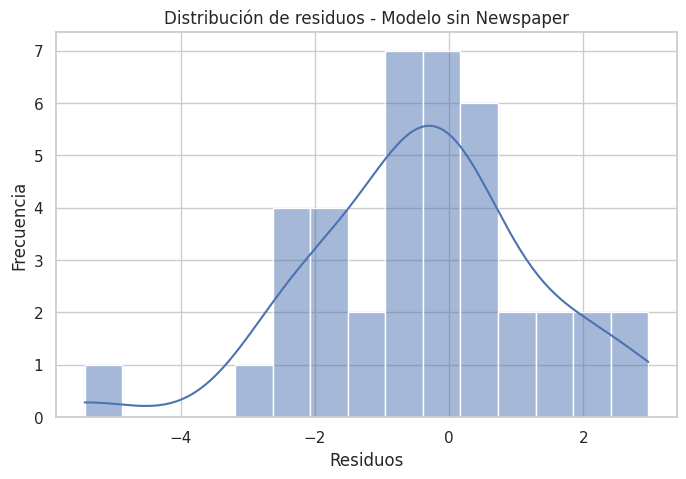

Prueba de Shapiro-Wilk:
Estadístico: 0.971346689495279
p-value: 0.3966464156486731
Interpretación: no se rechaza la hipótesis de normalidad de los residuos.


In [24]:
residuals_red = y_test_red - y_pred_red

plt.figure(figsize=(8, 5))
sns.histplot(residuals_red, kde=True, bins=15)
plt.title("Distribución de residuos - Modelo sin Newspaper")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

shapiro_stat_red, shapiro_p_red = stats.shapiro(residuals_red)

print("Prueba de Shapiro-Wilk:")
print("Estadístico:", shapiro_stat_red)
print("p-value:", shapiro_p_red)

if shapiro_p_red > 0.05:
    print("Interpretación: no se rechaza la hipótesis de normalidad de los residuos.")
else:
    print("Interpretación: se rechaza la hipótesis de normalidad de los residuos.")

### 6.3 Homocedasticidad

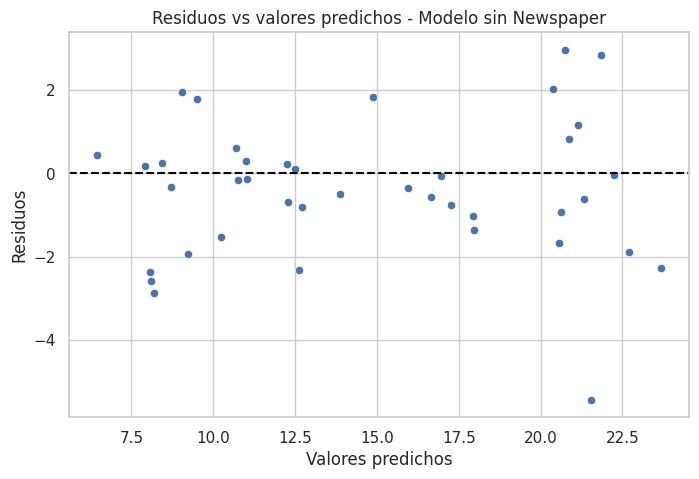

Interpretación:
- Se observa si los residuos se distribuyen de manera aleatoria alrededor de cero.
- Si no hay patrón fuerte, el supuesto de homocedasticidad parece aceptable.


In [25]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_red, y=residuals_red)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residuos vs valores predichos - Modelo sin Newspaper")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.show()

print("Interpretación:")
print("- Se observa si los residuos se distribuyen de manera aleatoria alrededor de cero.")
print("- Si no hay patrón fuerte, el supuesto de homocedasticidad parece aceptable.")

### 6.4 Q-Q Plot

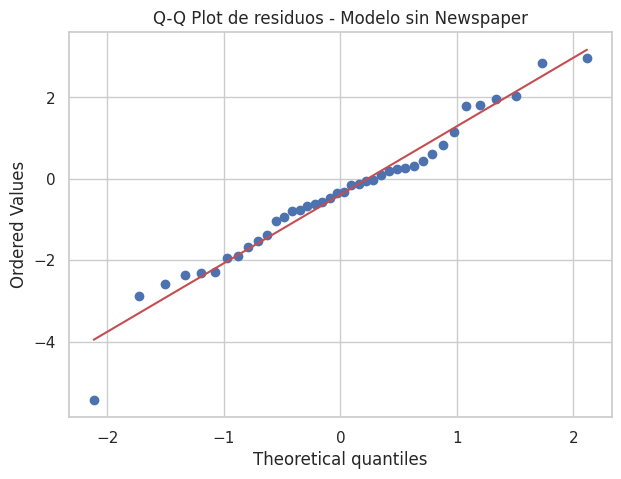

Interpretación:
- Los puntos cercanos a la línea diagonal sugieren que los residuos se aproximan a una distribución normal.


In [26]:
plt.figure(figsize=(7, 5))
stats.probplot(residuals_red, dist="norm", plot=plt)
plt.title("Q-Q Plot de residuos - Modelo sin Newspaper")
plt.show()

print("Interpretación:")
print("- Los puntos cercanos a la línea diagonal sugieren que los residuos se aproximan a una distribución normal.")

### 6.5 Evaluación del modelo

In [27]:
mse_red = mean_squared_error(y_test_red, y_pred_red)
rmse_red = np.sqrt(mse_red)
r2_red = r2_score(y_test_red, y_pred_red)

metrics_reduced = pd.DataFrame({
    "Modelo": ["Sin Newspaper"],
    "MSE": [mse_red],
    "RMSE": [rmse_red],
    "R2": [r2_red]
})

display(metrics_reduced)

print("Interpretación:")
print("- Este modelo usa menos variables y mantiene un rendimiento muy similar al modelo completo.")
print("- Si el R2 es igual o mayor y el RMSE es igual o menor, el modelo reducido puede considerarse preferible por ser más simple.")

,Modelo,MSE,RMSE,R2
0,Sin Newspaper,2.846616,1.687192,0.90788


Interpretación:
- Este modelo usa menos variables y mantiene un rendimiento muy similar al modelo completo.
- Si el R2 es igual o mayor y el RMSE es igual o menor, el modelo reducido puede considerarse preferible por ser más simple.


### 6.6 Visualización de predicciones

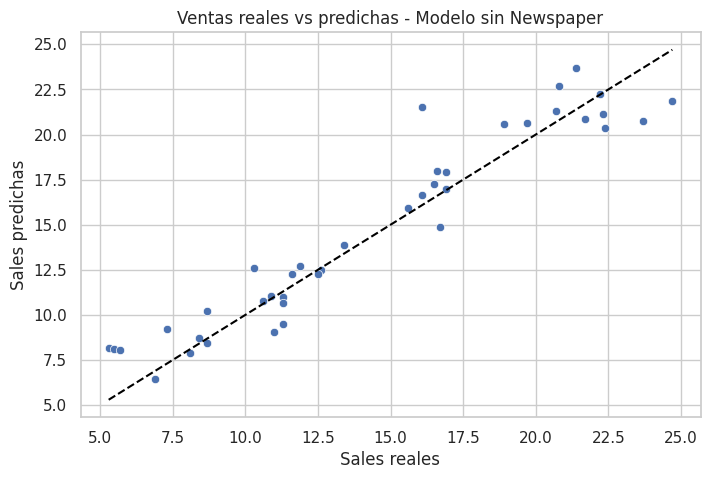

In [28]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test_red, y=y_pred_red)
plt.plot([y_test_red.min(), y_test_red.max()], [y_test_red.min(), y_test_red.max()], linestyle="--", color="black")
plt.title("Ventas reales vs predichas - Modelo sin Newspaper")
plt.xlabel("Sales reales")
plt.ylabel("Sales predichas")
plt.show()

### 6.7 Verificación con statsmodels

In [29]:
X_reduced_sm = sm.add_constant(X_reduced)
model_sm_reduced = sm.OLS(y, X_reduced_sm).fit()

print(model_sm_reduced.summary())

print("Interpretación:")
print("- TV y Radio tienen p-values menores a 0.05.")
print("- Esto indica que ambas variables son estadísticamente significativas para explicar Sales.")

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          2.39e-100
Time:                        19:36:19   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6309      0.290     15.952      0.0

## 7. Conclusiones

**¿Cuál de los tres modelos construidos fue el mejor?**  
El modelo sin `Newspaper`, es decir, el que usa únicamente `TV` y `Radio`, puede considerarse el mejor porque mantiene un desempeño igual o ligeramente superior al modelo completo y además es más simple. El modelo sin multicolinealidad es equivalente al modelo completo, ya que no fue necesario eliminar variables por VIF.

**¿Cuál fue el atributo que más influencia tiene en las ventas?**  
`TV` parece ser el atributo más influyente porque presenta la correlación más alta con `Sales` y es una variable estadísticamente significativa. Aunque el coeficiente de `Radio` puede ser mayor en magnitud, la inversión en `TV` muestra una relación más fuerte y clara con las ventas en el análisis exploratorio.

**Conclusión general:**  
El análisis muestra que la inversión en `TV` y `Radio` explica gran parte de la variabilidad de las ventas. `Newspaper` no aporta evidencia estadística fuerte dentro del modelo múltiple, por lo que eliminarla permite obtener un modelo más sencillo sin perder capacidad predictiva.